<a href="https://colab.research.google.com/github/itsabhiraj/Abhinav/blob/main/Accident_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
train_data = pd.read_csv('train.csv')
train_data

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [ ]:
test_data=pd.read_csv('test.csv')
test_data

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172580,690334,rural,2,0.01,45,dim,rainy,False,False,afternoon,True,True,2
172581,690335,rural,1,0.74,70,daylight,foggy,False,True,afternoon,False,False,2
172582,690336,urban,2,0.14,70,dim,clear,False,False,evening,True,True,1
172583,690337,urban,1,0.09,45,daylight,foggy,True,True,morning,False,True,0


Categorical columns

In [ ]:
cat_cols = [col for col in train_data.columns if train_data[col].dtype == 'object']
cat_cols

['road_type', 'lighting', 'weather', 'time_of_day']

Numerical columns

In [ ]:
num_cols = [col for col in test_data.columns if train_data[col].dtype != 'object']
num_cols

['id',
 'num_lanes',
 'curvature',
 'speed_limit',
 'road_signs_present',
 'public_road',
 'holiday',
 'school_season',
 'num_reported_accidents']

In [ ]:
for col in num_cols:
  print(col)
  print(train_data[col].corr(train_data['accident_risk']))

id
0.0009690583945969552
num_lanes
-0.006003383239601338
curvature
0.5439459306734995
speed_limit
0.43089799710043086
road_signs_present
0.0006293770646803836
public_road
0.031032368658651742
holiday
0.051128955289721535
school_season
-0.000976887450713251
num_reported_accidents
0.21389091594840867


Missing value count

In [ ]:
train_data.isnull().sum()

,0
id,0
road_type,0
num_lanes,0
curvature,0
speed_limit,0
lighting,0
weather,0
road_signs_present,0
public_road,0
time_of_day,0


In [ ]:
test_data.isnull().sum()

,0
id,0
road_type,0
num_lanes,0
curvature,0
speed_limit,0
lighting,0
weather,0
road_signs_present,0
public_road,0
time_of_day,0


/tmp/ipython-input-4132202963.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


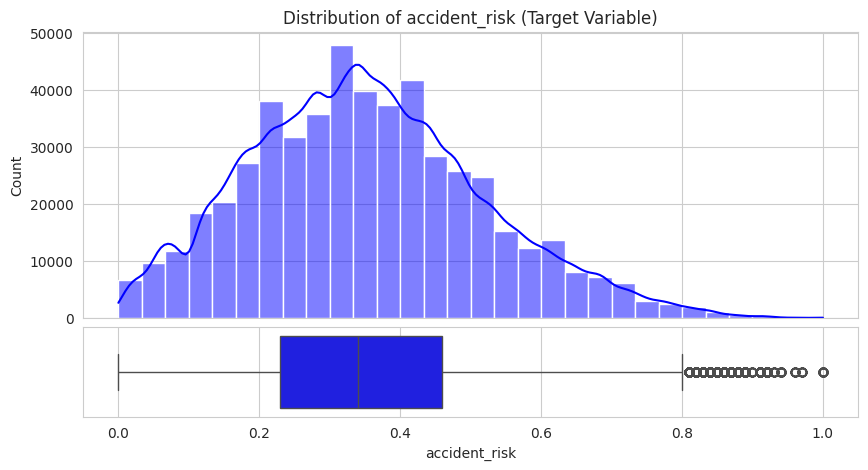

In [ ]:
y_train = train_data['accident_risk']

fig = plt.figure(figsize=(10, 5))
grid = plt.GridSpec(4, 1, hspace=0.1)
ax_hist = fig.add_subplot(grid[0:3, 0])
ax_box = fig.add_subplot(grid[3, 0], sharex=ax_hist)

sns.histplot(y_train, bins=30, kde=True, color='blue', ax=ax_hist, legend=False)
ax_hist.set_title("Distribution of accident_risk (Target Variable)")
ax_hist.set_xlabel("")

sns.boxplot(x=y_train, ax=ax_box, color='blue')
ax_box.set_xlabel("accident_risk")

plt.setp(ax_hist.get_xticklabels(), visible=False)
plt.tight_layout()
plt.show()

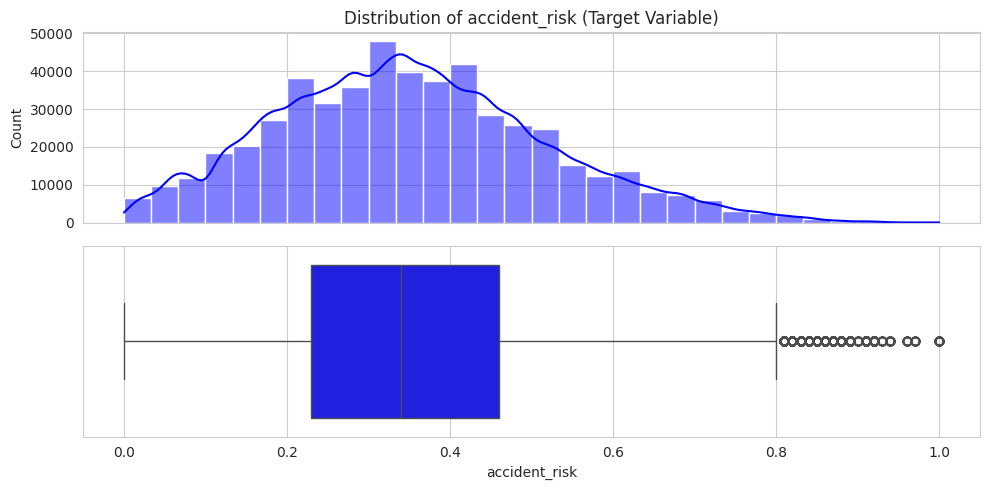

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

sns.histplot(y_train, bins=30, kde=True, color='blue', ax=axes[0])
sns.boxplot(x=y_train, color='blue', ax=axes[1])

axes[0].set_title("Distribution of accident_risk (Target Variable)")
plt.tight_layout()
plt.show()

Distribution of numeric features

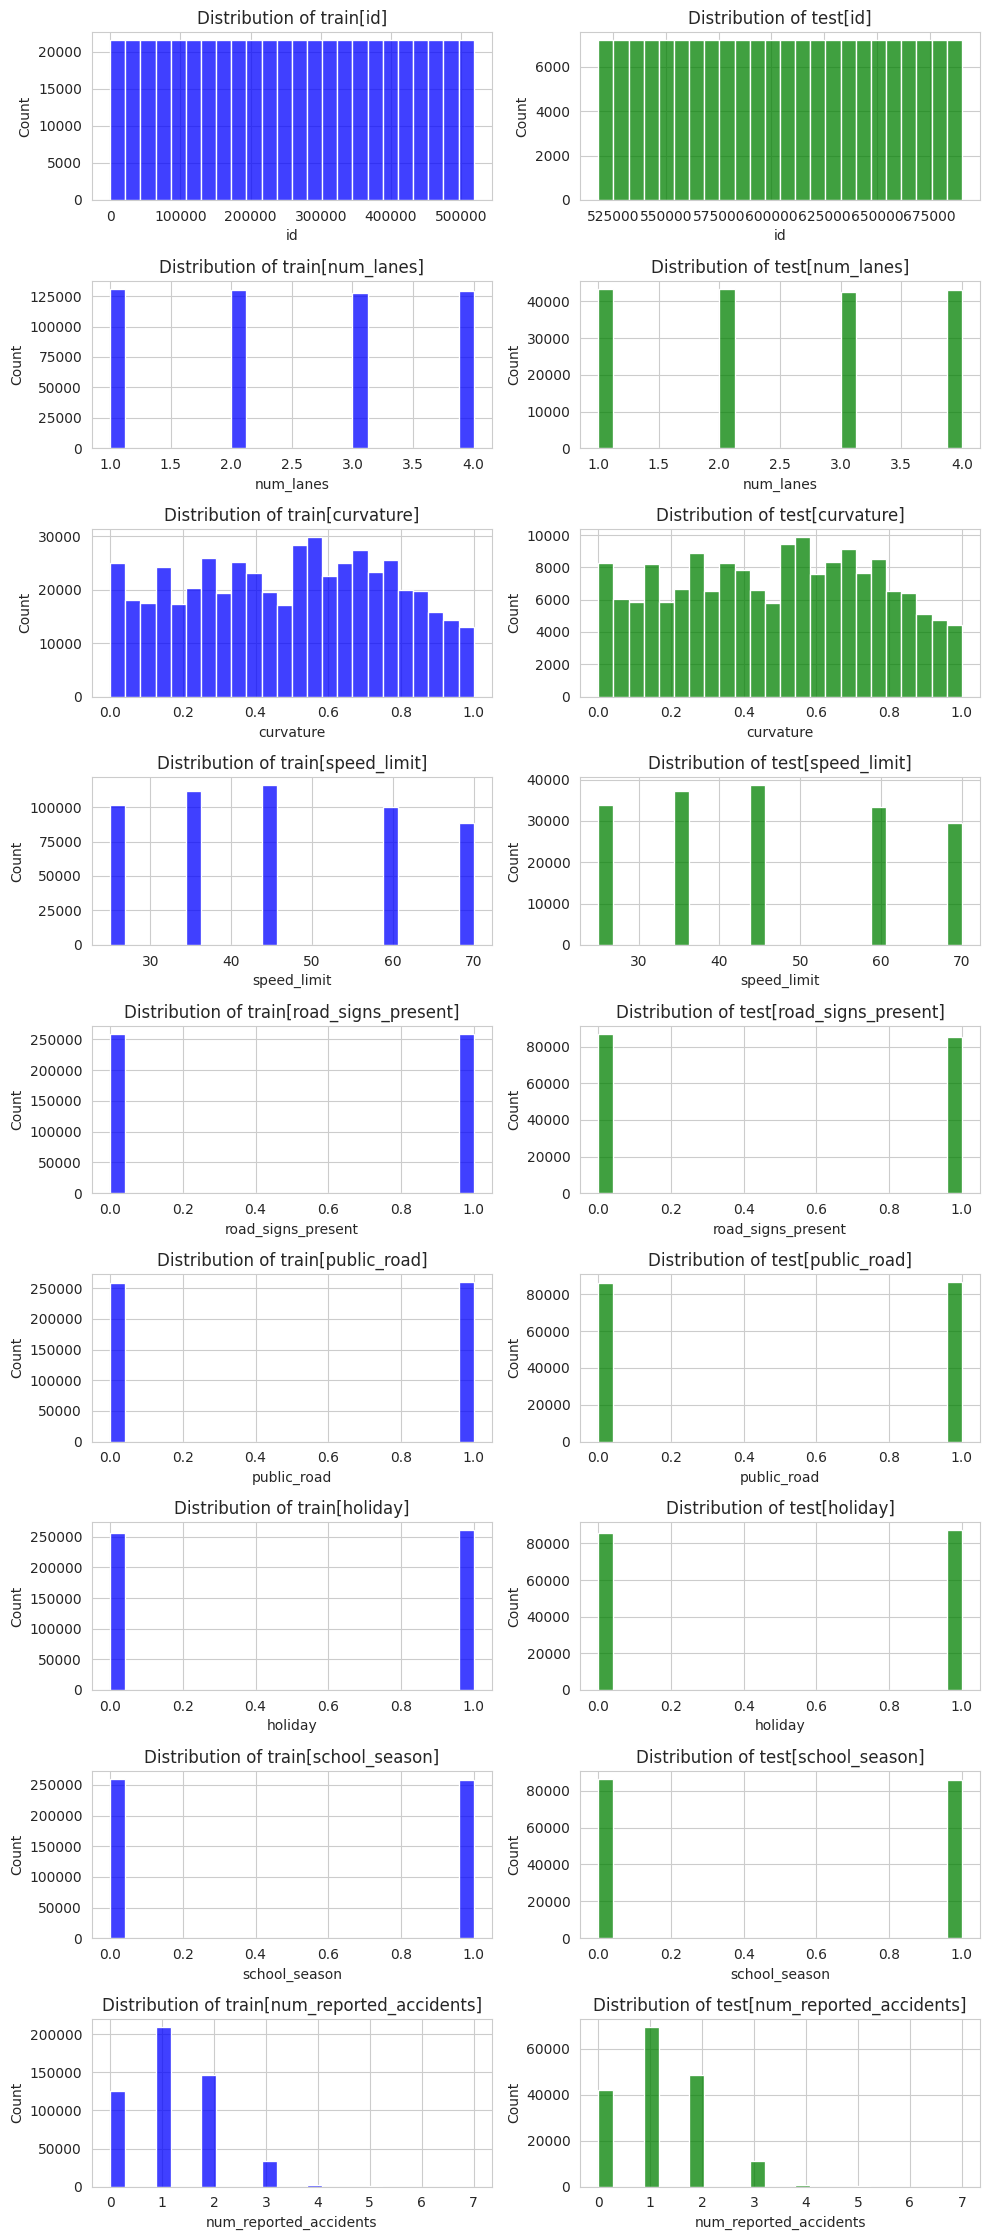

In [ ]:
plt.figure(figsize=(10, len(num_cols)*2.5))

for i,cols in enumerate(num_cols):
  plt.subplot(len(num_cols), 2, i*2+1)
  sns.histplot(train_data[cols], bins=24, color='blue')
  plt.title(f"Distribution of train[{cols}]")
  plt.xlabel(cols)

  plt.subplot(len(num_cols), 2, i*2+2)
  sns.histplot(test_data[cols], bins=24, color='green')
  plt.title(f"Distribution of test[{cols}]")
  plt.xlabel(cols)

plt.tight_layout()
plt.show()


In [ ]:
for col in cat_cols:
  print(f"{col} : {train_data[col].unique()}")
  print("--"*25)

road_type : ['urban' 'rural' 'highway']
--------------------------------------------------
lighting : ['daylight' 'dim' 'night']
--------------------------------------------------
weather : ['rainy' 'clear' 'foggy']
--------------------------------------------------
time_of_day : ['afternoon' 'evening' 'morning']
--------------------------------------------------


Comparison for categorical columns

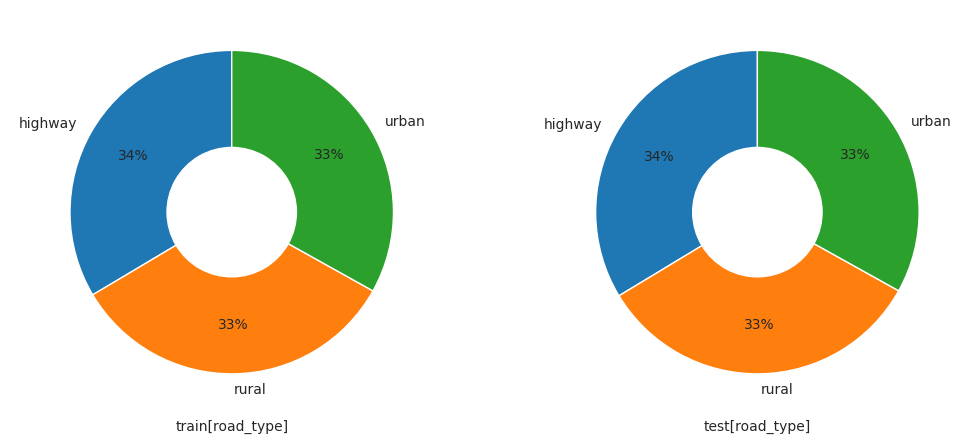

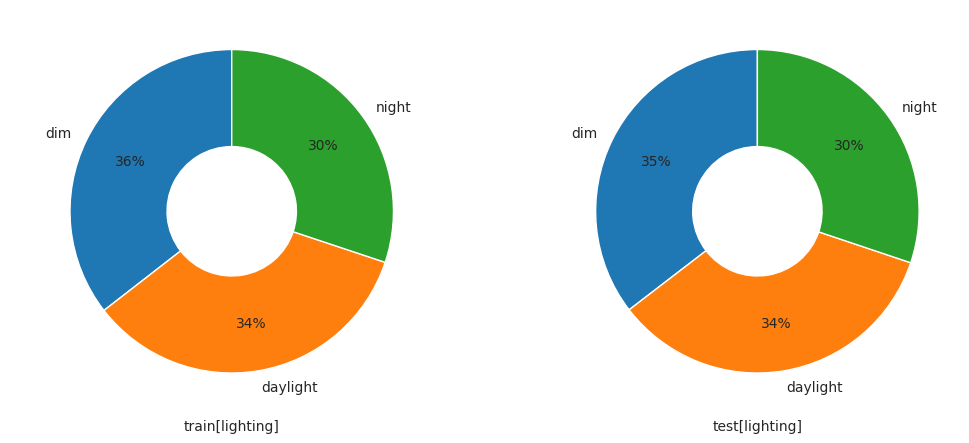

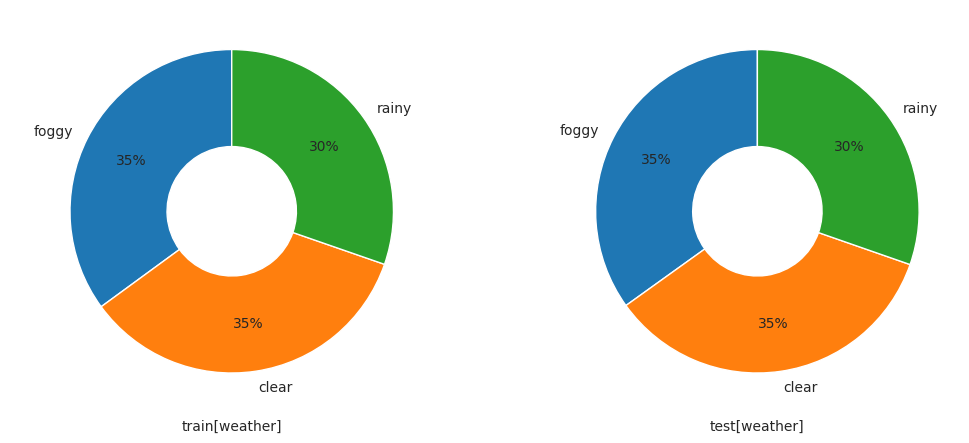

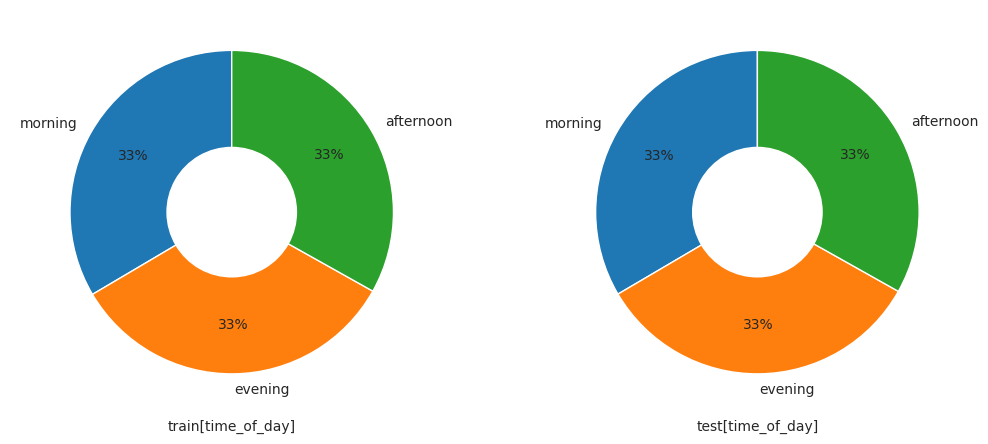

In [ ]:
for col in cat_cols:

  sns.set_style("whitegrid")
  fig,axes = plt.subplots(1,2, figsize=(12,6))
  plt.subplots_adjust(wspace=0.3)

  train_data[col].value_counts().plot.pie(
      ax=axes[0],
      pctdistance=0.7,
      autopct='%1.f%%',
      wedgeprops=dict(width=0.6),
      startangle=90)
  axes[0].set_ylabel(" ")
  axes[0].set_xlabel(f"train[{col}]")

  test_data[col].value_counts().plot.pie(
      ax=axes[1],
      pctdistance=0.7,
      autopct='%1.f%%',
      wedgeprops=dict(width=0.6),
      startangle=90)
  axes[1].set_ylabel(" ")
  axes[1].set_xlabel(f"test[{col}]")

  plt.show()


Ordinal encoding

In [ ]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [ ]:
ordinal_columns = [
    'road_type',
    'lighting',
    'weather',
    'time_of_day']

ordinal_categories = [
    ['rural', 'urban', 'highway'],         # road_type
    ['daylight', 'dim', 'night'],          # lighting
    ['clear', 'rainy', 'foggy'],           # weather
    ['morning', 'afternoon', 'evening']]   # time_of_day]

# Create an instance of OrdinalEncoder with the specified categories
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

# Apply the OrdinalEncoder to the training data and test data
train_data[ordinal_columns] = ordinal_encoder.fit_transform(train_data[ordinal_columns])
test_data[ordinal_columns] = ordinal_encoder.transform(test_data[ordinal_columns])

In [ ]:
# from sklearn.preprocessing import OneHotEncoder

# # Columns to one-hot encode
# onehot_columns = [
#     'road_type',
#     'lighting',
#     'weather',
#     'time_of_day'
# ]

# # Create the OneHotEncoder
# onehot_encoder = OneHotEncoder(sparse_output=False, drop=None, handle_unknown='ignore')

# # Fit on train and transform both train & test
# train_encoded = onehot_encoder.fit_transform(train_data[onehot_columns])
# test_encoded = onehot_encoder.transform(test_data[onehot_columns])

# # Convert encoded arrays to DataFrames with proper column names
# encoded_col_names = onehot_encoder.get_feature_names_out(onehot_columns)
# train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_col_names, index=train_data.index)
# test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_col_names, index=test_data.index)

# # Drop original categorical columns and concatenate encoded ones
# train_data = pd.concat([train_data.drop(columns=onehot_columns), train_encoded_df], axis=1)
# test_data = pd.concat([test_data.drop(columns=onehot_columns), test_encoded_df], axis=1)


In [ ]:
columns=test_data.columns
scaler = StandardScaler()
train_data[columns] = scaler.fit_transform(train_data[columns])
test_data[columns] = scaler.transform(test_data[columns])

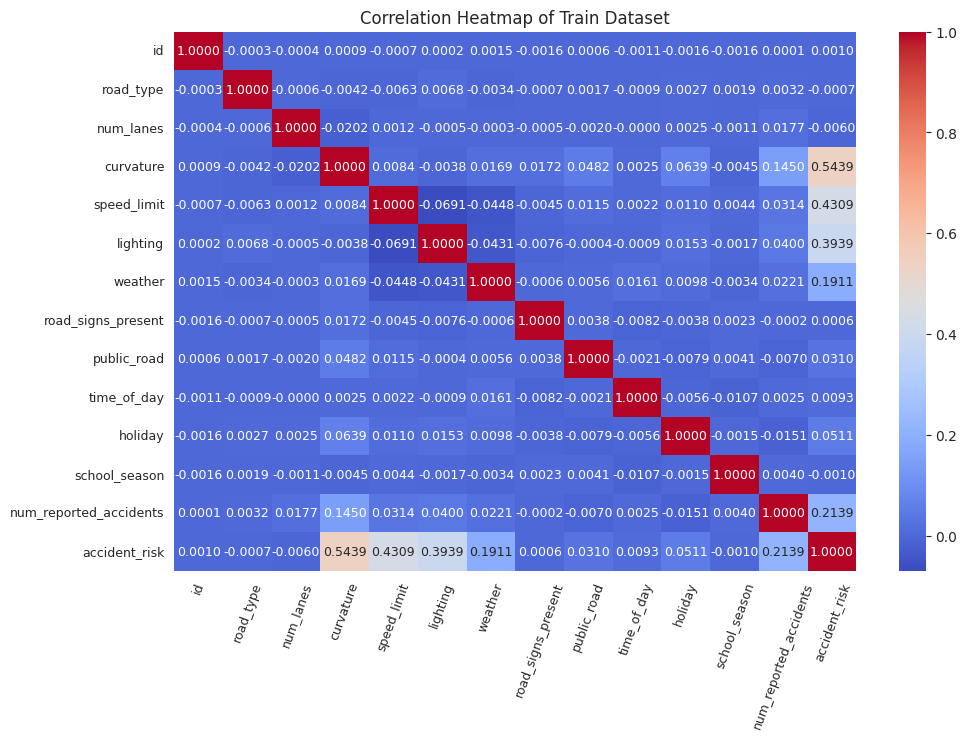

In [ ]:
plt.figure(figsize=(11, 7))
heatmap=sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt=".4f", annot_kws={"size":9})
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=70, fontsize=9)
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=9)
plt.title('Correlation Heatmap of Train Dataset')
plt.show()

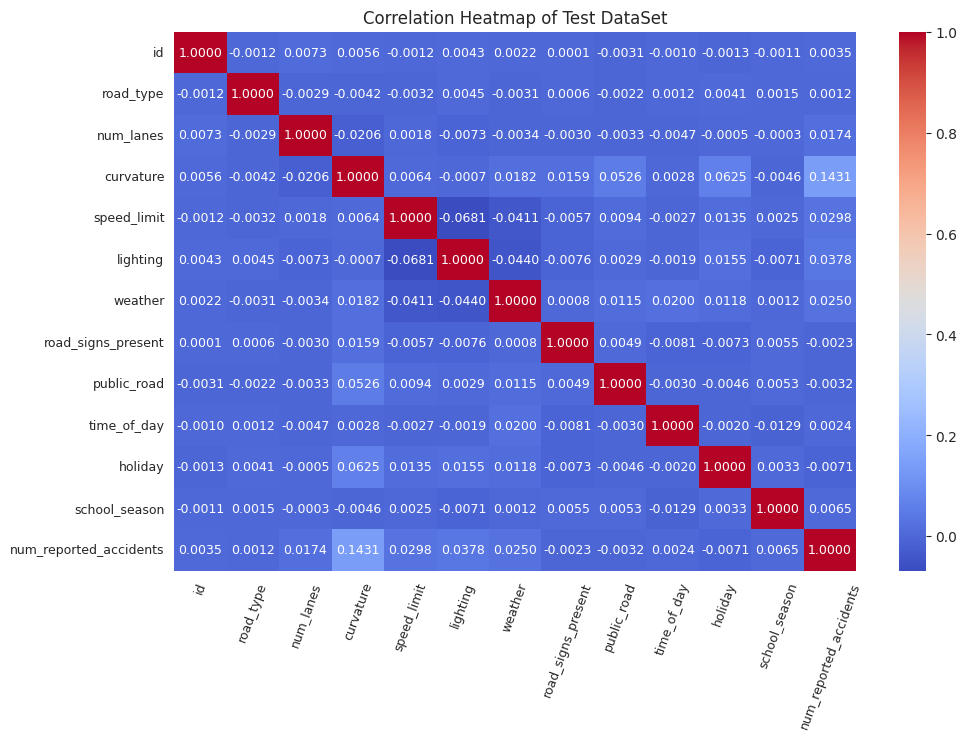

In [ ]:
# Correlation Heatmap of Test Dataset

plt.figure(figsize=(11, 7))
heatmap=sns.heatmap(test_data.corr(), annot=True, cmap='coolwarm', fmt=".4f", annot_kws={"size":9})
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=70, fontsize=9)
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=9)
plt.title('Correlation Heatmap of Test DataSet')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train = train_data.drop('accident_risk', axis=1)
y_train = train_data['accident_risk']

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input, BatchNormalization, Activation, Dropout
from keras.regularizers import l2
from keras.metrics import RootMeanSquaredError
from keras.callbacks import EarlyStopping, Callback
from keras.utils import plot_model

In [ ]:
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(128, kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.1),

    Dense(128, kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.1),

    Dense(64, kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.1),
    Dense(1)
])

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=[RootMeanSquaredError()])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,905 (109.00 KB)

 Trainable params: 27,265 (106.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [115]:
search = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=2048,
    validation_data=(x_val, y_val),
    verbose=0)


In [116]:
y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)

12944/12944 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step
3236/3236 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [117]:
y_test_pred = model.predict(test_data)

5394/5394 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step


In [118]:
submission = pd.read_csv('sample_submission.csv')
submission['accident_risk'] = y_test_pred
submission.to_csv('submission.csv', index=False)